# Analise Exploratoria - Deteccao de Anomalias em Campanhas de E-mail Marketing

Visualiza series temporais de `taxa_abertura` e `ctr` para campanhas de exemplo,
sobrepondo tres fontes de sinal:

- **Anomalia real injetada** (gabarito) — o que de fato foi simulado
- **Deteccao via z-score** (por campanha, ver `detect_anomalies_zscore.py`)
- **Deteccao via Isolation Forest** (por campanha, ver `detect_anomalies_ml.py`)

O objetivo e evidenciar visualmente onde os metodos acertam, erram e onde ha
sobreposicao entre eles.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
RAW_DIR = BASE_DIR / "data" / "raw"
OUTPUTS_DIR = BASE_DIR / "outputs"

sys.path.insert(0, str(BASE_DIR / "src"))
import visualization as viz

viz.aplicar_estilo_padrao()

In [2]:
agregado = pd.read_csv(PROCESSED_DIR / "fato_agregado_diario.csv", parse_dates=["dat_referencia"])
gabarito = pd.read_csv(RAW_DIR / "gabarito_anomalias.csv")
zscore = pd.read_csv(OUTPUTS_DIR / "anomalias_zscore.csv", parse_dates=["dat_referencia"])
isolation_forest = pd.read_csv(OUTPUTS_DIR / "anomalias_isolation_forest.csv", parse_dates=["dat_referencia"])

print(f"{len(agregado)} disparos agregados, {len(gabarito)} disparos no gabarito.")
print(f"{len(zscore)} linhas de deteccao zscore, {len(isolation_forest)} linhas de deteccao isolation_forest.")

625 disparos agregados, 625 disparos no gabarito.
1875 linhas de deteccao zscore, 625 linhas de deteccao isolation_forest.


## Selecionando campanhas de exemplo

Escolhemos as campanhas com maior diversidade de tipos de anomalia injetada no
gabarito (`queda_deliverability`, `clique_bot`, `pico_engajamento`), para
ilustrar os tres cenarios no menor numero de exemplos possivel.

In [3]:
campanhas_exemplo = viz.selecionar_campanhas_exemplo(gabarito, n=4)
print("Campanhas de exemplo selecionadas:", campanhas_exemplo)

Campanhas de exemplo selecionadas: [1, 3, 10, 27]


## Graficos por campanha

A funcao plotar_campanha (src/visualization.py, reutilizada pelo app
Streamlit) plota, para cada campanha, dois paineis empilhados (`taxa_abertura` e `ctr`) ao longo
dos disparos (`id_disparo`). Marcadores sobrepostos a linha indicam:

- **X vermelho**: anomalia real (gabarito)
- **Triangulo violeta (contorno)**: deteccao z-score
- **Quadrado laranja (contorno)**: deteccao Isolation Forest

Quando os tres simbolos coincidem no mesmo disparo, houve acerto (verdadeiro
positivo). Um X vermelho sem nenhum marcador de metodo ao redor e um falso
negativo; um marcador de metodo sem X vermelho correspondente e um falso
positivo — atencao especial aos disparos de `pico_engajamento`, que sao
anomalias estatisticas "boas" e idealmente nao deveriam ser marcadas como
problema (ver `evaluate.py`).

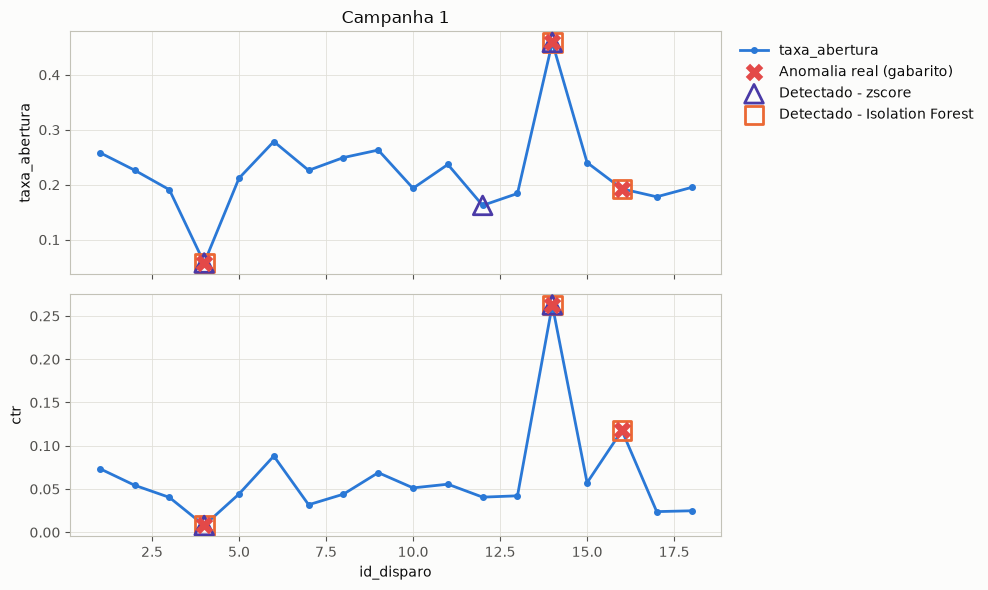

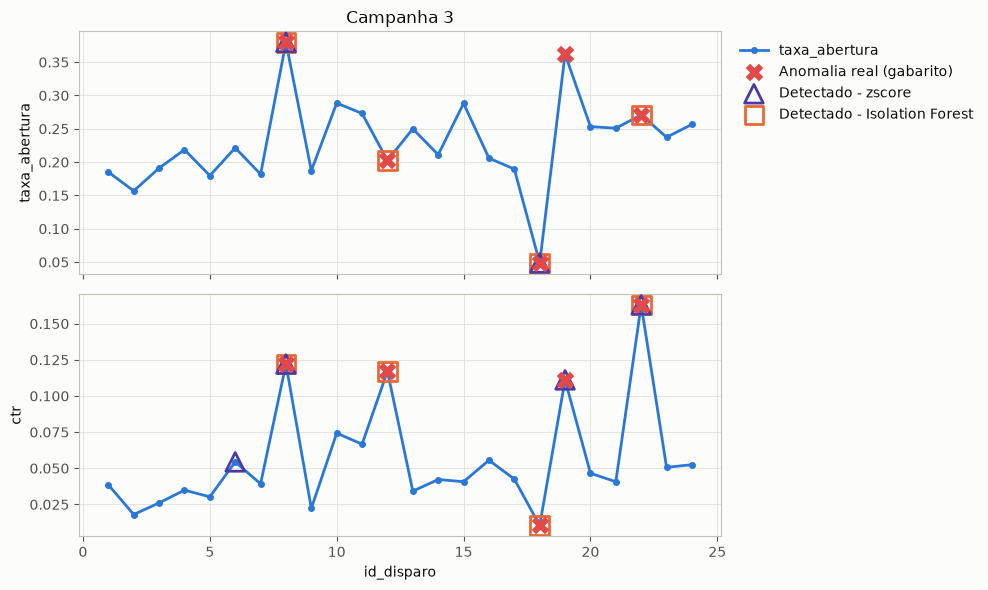

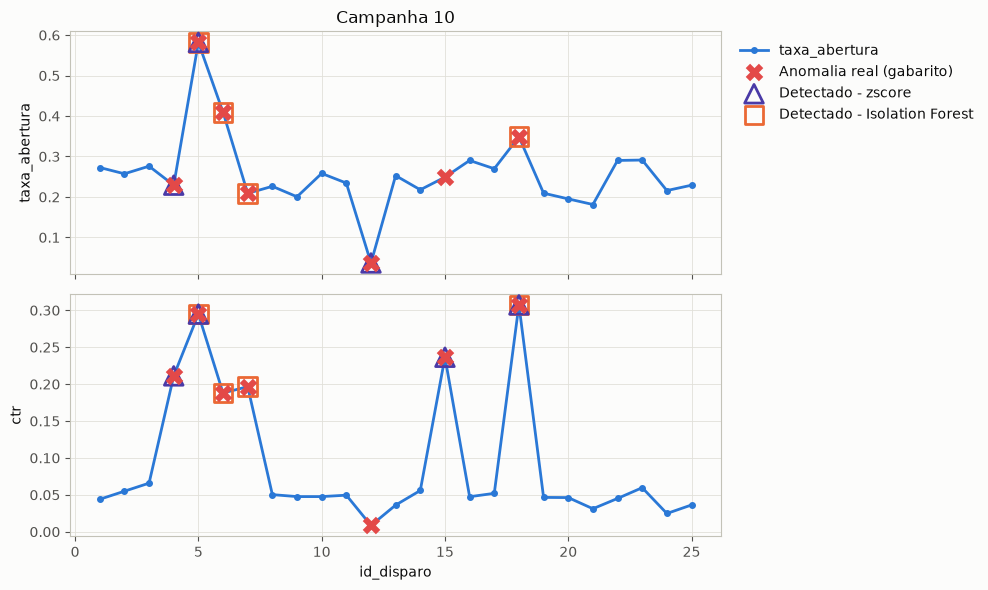

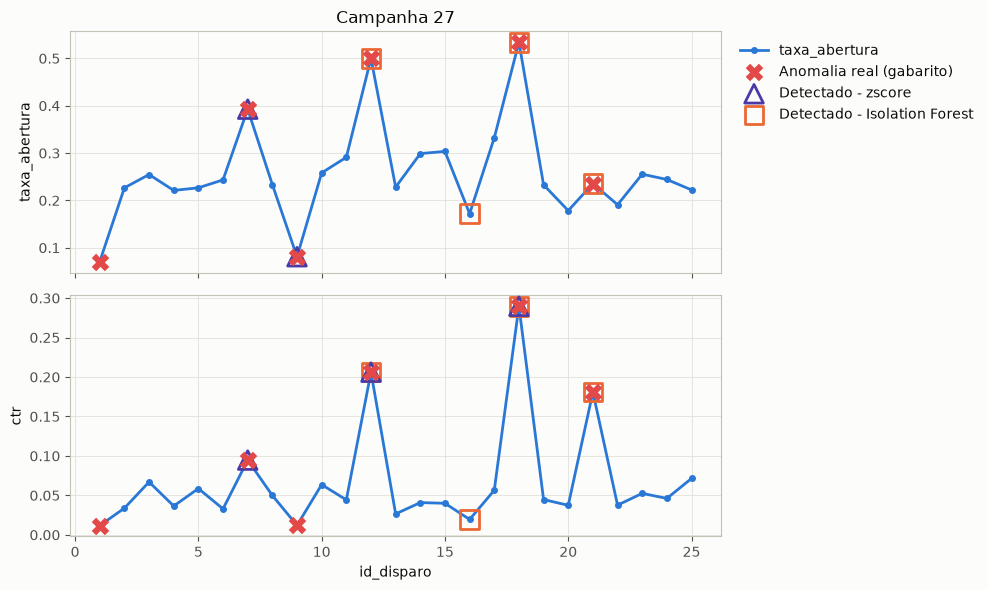

In [4]:
for id_campanha in campanhas_exemplo:
    fig = viz.plotar_campanha(id_campanha, agregado, gabarito, zscore, isolation_forest)
    plt.show()

## Observacoes

- Nas campanhas selecionadas, os disparos de `queda_deliverability` aparecem
  como um vale isolado em `taxa_abertura`, geralmente capturado por ambos os
  metodos.
- Os disparos de `clique_bot` sobem em `ctr` sem uma subida equivalente em
  `taxa_abertura` no mesmo disparo — e o padrao que o Isolation Forest, por
  ser multivariado, tende a capturar melhor que o z-score (ver
  `outputs/comparativo_metodos.csv`).
- Os disparos de `pico_engajamento` sobem em ambas as metricas ao mesmo
  tempo. Repare que, quando marcados por algum metodo, isso e um falso
  alarme esperado no cenario atual — nenhum dos dois detectores usa a
  direcao do desvio, entao um pico bom pode ser confundido com anomalia.